Jakub Biedrzycki, 76619, jbiedrzycki@st.swps.edu.pl

# Temat projektu: Analiza wpływu rozwoju sztucznej inteligencji na wycenę sektora energetycznego

# Definicja problemu
Kontekst: Rozwój generatywnej sztucznej inteligencji od roku 2022 generuje zapotrzebowanie na moc obliczeniową i energię elektryczną. Centra danych (Data Centers) stają się kluczowym elementem infrastruktury cyfrowej, a ich zapotrzebowanie na stabilne zasilanie rośnie.

Cel analizy: Celem projektu jest zbadanie, czy istnieje statystyczna zależność między wyceną lidera rynku AI (Nvidia) a sektorami odpowiedzialnymi za dostarczanie energii i infrastruktury.

Hipotezy:

H0: Nie istnieje statystycznie istotna zależność między wyceną sektora AI a wyceną sektora energetycznego.

H1: Istnieje statystycznie istotna zależność między wyceną sektora AI a wyceną sektora energetycznego.

# Pozyskanie danych
Dane rzędu dziennego (ceny zamknięcia - Close) zostały pobrane automatycznie za pomocą biblioteki yfinance.

Analizowane instrumenty:

AI (Nvidia - NVDA): Zmienna niezależna (proxy dla popytu na technologię)

Atom (Cameco - CCJ): Największy producent uranu (proxy dla stabilnej energii jądrowej)

Sieci (Eaton - ETN): Producent osprzętu energetycznego (proxy dla modernizacji sieci)

OZE (iShares Global Clean Energy - ICLN): Zbiór spółek OZE (wiatr, słońce)

Zakres czasowy: od 01.01.2022 do chwili obecnej (po premierze ChatGPT).

In [7]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
from statsmodels.tsa.api import VAR
from statsmodels.tools.eval_measures import rmse
from statsmodels.tsa.stattools import grangercausalitytests

tickers = {
    'NVDA': 'AI (Nvidia)', #lider technologiczny
    'CCJ': 'Atom (Cameco)', #paliwo jądrowe (jako reprezentacja stabilności)
    'ETN': 'Sieci (Eaton)', #infrastruktura (przesył - sieci)
    'ICLN': 'OZE (Clean Energy)' #odnawialne źródła energii (OZE)
}

#Eksploracja i przygotowanie danych
Przed modelowaniem dane zostały obrobione:

Czyszczenie: Uzupełnione braki danych (różnice w dniach handlowych) metodą ffill oraz ustawienie częstotliwości na dni robocze (Business Day).

Transformacja: Przekształcone surowe ceny na logarytmiczne stopy zwrotu w celu uzyskania stacjonarności szeregów czasowych, co jest wymogiem modelu VAR. Dodatkowo różnicowanie, aby pozbyć się trendu.

[*********************100%***********************]  4 of 4 completed


Pobrano 1021 wierszy danych.


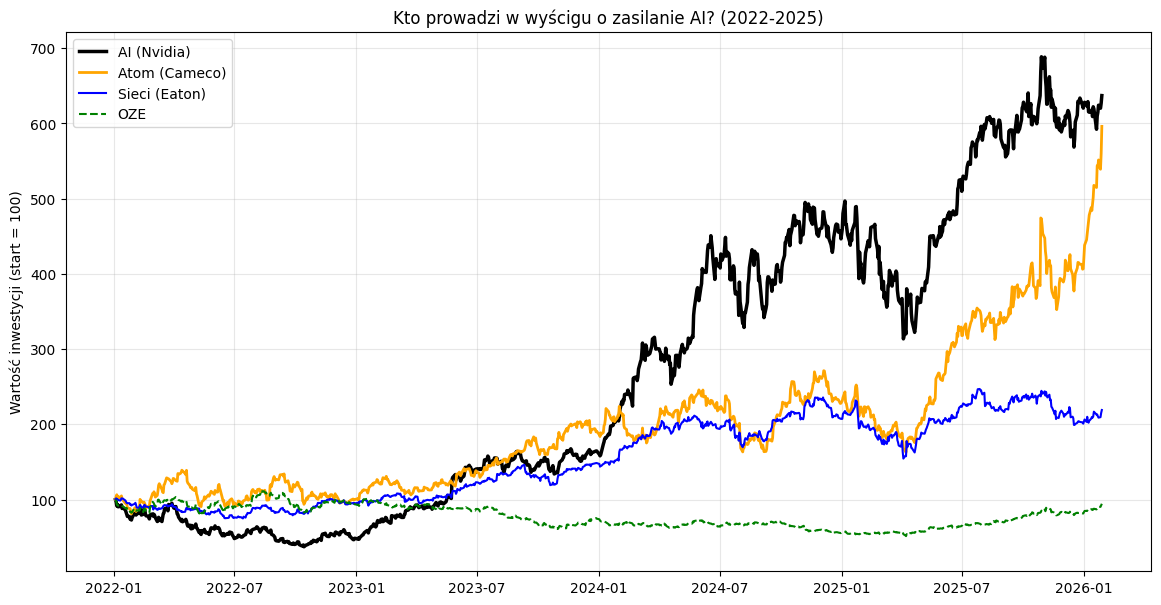

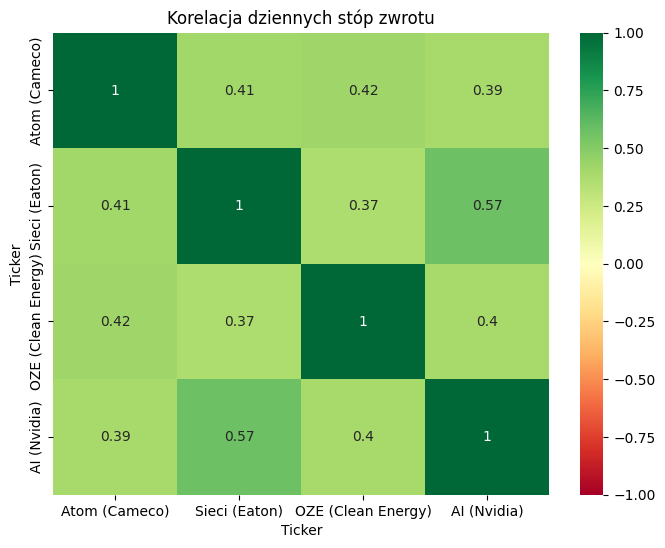

In [8]:
raw_data = yf.download(list(tickers.keys()), start="2022-01-01", end=datetime.now(), auto_adjust=True) #auto_adjust=True koryguje ceny o splity i dywidendy

df = raw_data['Close'].rename(columns=tickers) #ceny zamknięcia + zmiana nazw kolumn na te ze slownika tickers
df = df.ffill().dropna() #uzupełnianie danych - forward fill (zamiast usuwania)

print(f"Pobrano {len(df)} wierszy danych.")

#wizualizacja
df_norm = (df / df.iloc[0]) * 100 #normalizacja (bazowo 100; punkt odniesienia)

plt.figure(figsize=(14, 7))
plt.plot(df_norm.index, df_norm['AI (Nvidia)'], label='AI (Nvidia)', color='black', linewidth=2.5)
plt.plot(df_norm.index, df_norm['Atom (Cameco)'], label='Atom (Cameco)', color='orange', linewidth=2)
plt.plot(df_norm.index, df_norm['Sieci (Eaton)'], label='Sieci (Eaton)', color='blue', linewidth=1.5)
plt.plot(df_norm.index, df_norm['OZE (Clean Energy)'], label='OZE', color='green', linestyle='--')
plt.title("Kto prowadzi w wyścigu o zasilanie AI? (2022-2025)")
plt.ylabel("Wartość inwestycji (start = 100)") #punkt odniesienia
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

#macierz korelacji (heatmapa)
plt.figure(figsize=(8, 6))
sns.heatmap(df.pct_change().corr(), annot=True, cmap='RdYlGn', vmin=-1, vmax=1) #pct_change() to procentowe zmianny dzienne
plt.title("Korelacja dziennych stóp zwrotu")
plt.show()

#Stworzenie modelu
VAR, który pozwala badać wiele zmiennych i ich wzajemne interakcje w czasie.

Algorytm AIC dobrał optymalny rząd opóźnienia: Lag = 1

Oznacza to, że model bierze pod uwagę dane z jednego dnia wstecz do prognozowania bieżących wartości.

In [9]:
#model VAR
#logarytmowanie, aby zminiejszyć wariancję w danych (wymagane dla stacjonarności - stala średnia i wariancja w czasie)
df_log = np.log(df)
#różnicowanie, aby usunąć trend - zostawić samą zmianę z dnia na dzien tzw. szum
df_diff = df_log.diff().dropna()
df_diff = df_diff.asfreq('B').ffill() #.asfreq('B') ustawiamy częstotliwość na dni robocze (business day); fill forward, jesli brakuje danych

#podzial na trening i test
train = df_diff[:-15]
test = df_diff[-15:]

model = VAR(train)

#automatyczny wybór opóźnienia (lag); AIC - najdokładniejszy wynik przy najmniejszym skomplikowaniu
safe_maxlags = min(15, len(train) // 2 - 1) #ograniczenie maxlags, aby uniknac błędów przy małej ilości danych
x = model.select_order(maxlags=safe_maxlags)
chosen_lag = x.aic if x.aic > 0 else 1 #jesli wybierze 0 to biorę 1
print(f"Opóźnienie (Lag): {chosen_lag}")

#trenowanie
results = model.fit(chosen_lag)

#pobranie danych wejściowych do prognozy
forecast_input = train.values[-chosen_lag:]
fc = results.forecast(y=forecast_input, steps=15)
df_forecast = pd.DataFrame(fc, index=test.index, columns=test.columns) #prognoza

Opóźnienie (Lag): 1


#Walidacja/ocena modelu
Jakość modelu została oceniona na zbiorze testowym (ostatnie 15 dni) przy użyciu metryki RMSE (Root Mean Squared Error).
Stopy zwrotu -> błąd rzędu 0.01 oznacza odchylenie o 1%.

In [11]:
#obliczenie RMSE (błędu), RMSE jest najczęściej używaną metryką
print("Błędy prognozy (RMSE):")
for col in test.columns:
    error = rmse(test[col], df_forecast[col])
    print(f"  {col}: {error:.4f}")

Błędy prognozy (RMSE):
  Atom (Cameco): 0.0282
  Sieci (Eaton): 0.0161
  OZE (Clean Energy): 0.0131
  AI (Nvidia): 0.0182


Wyniki walidacji:

Atom (Cameco): Błąd ~2.78% - Średnia precyzja

Sieci (Eaton): Błąd ~1.61% - Wysoka precyzja

OZE (Clean Energy): Błąd ~1.31% - Bardzo wysoka precyzja

AI (Nvidia): Błąd ~1.82% - Dobra precyzja

Model VAR bardzo dobrze radzi sobie z przewidywaniem zachowania sektora OZE i sieci, co świadczy o silnym powiązaniu tych zmiennych. Wyższy błąd dla atomu wynika ze specyfiki surowcowej tej spółki i jej wysokiej zmienności.

#Opis obserwacji i wniosków
Test przyczynowości Grangera

In [13]:
#test Grangera
print("Test Grangera\n")
targets = ['Atom (Cameco)', 'Sieci (Eaton)', 'OZE (Clean Energy)']
cause = 'AI (Nvidia)'
for target in targets:
    print(f"Czy [{cause}] wpływa na [{target}]?")
    try:
        #test dla wybranego laga
        res = grangercausalitytests(df_diff[[target, cause]], maxlag=[chosen_lag], verbose=False)
        #p-value dla testu ssr_ftest
        p_value = res[chosen_lag][0]['ssr_ftest'][1]

        print(f"-> p-value: {p_value:.4f}")
        if p_value < 0.05:
            print("Wynik istotny: wzrost AI (Nvidia) zapowiada ruchy w tym sektorze")
        else:
            print("Brak istotności w krótkim terminie")
    except Exception as e:
        print(f"  Błąd obliczeń: {e}")
    print("-" * 40)

Test Grangera

Czy [AI (Nvidia)] wpływa na [Atom (Cameco)]?
-> p-value: 0.4678
Brak istotności w krótkim terminie
----------------------------------------
Czy [AI (Nvidia)] wpływa na [Sieci (Eaton)]?
-> p-value: 0.2090
Brak istotności w krótkim terminie
----------------------------------------
Czy [AI (Nvidia)] wpływa na [OZE (Clean Energy)]?
-> p-value: 0.1508
Brak istotności w krótkim terminie
----------------------------------------


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/stattools.py:1556: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/stattools.py:1556: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/stattools.py:1556: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(


Wyniki testu (dla Lag=1):

AI -> Atom: Brak istotności w którtkim terminie.

AI -> Sieci: Brak istotności w którtkim terminie.

AI -> OZE: Brak istotności w którtkim terminie.

Wnioski końcowe:

Nie możemy jednoznacznie odrzucić hipotezy zero (H0) ze względu na wartości p większe od 0.05. Tym samym, w interwale dziennym, nie istnieje statystycznie istotna zależność między wyceną sektora AI a wyceną sektora energetycznego.

Brak przyczynowości Grangera w modelu dziennym nie oznacza braku związku, lecz świadczy o wysokiej efektywności informacyjnej rynku. Newsy o centrach danych skutkują inwestycjami w tym samym czasie dla sektora technologicznego i energetycznego. Reakcja inwestorów jest natychmiastowa. Ruch akcji jest jednoczesny.

